## Data Cleaning, Preprocessimg  and Dimensionality Reduction

In this notebook,the main objective here after learing about the shape of our data from the EDA section is to drop columns we will not be needing, handle null values, scale our features, reduce dimensionality and finally save the cleaned dataset for our modelling.

In [ ]:
# Importing basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

import warnings
warnings.filterwarnings('ignore')



In [79]:
#Loading our dataset

df = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train.csv')

In [80]:
# Checking the shape of the dataset

print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 28362 rows and 24 columns.


In [81]:
#checking the information about the dataset

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

In [82]:
# Now lets drop columns we will not need for our model.

#K-means can only work with numerical data, so we will drop the 'artist_name', 'release_date',lyrics,genre and 'song_name' columns.
cols_to_drop = ['artist_name', 'release_date','lyrics','genre','track_name']

#lets make a copy of the original dataframe before dropping the columns
df_features = df.drop(columns=cols_to_drop)

print(f"shape of the new dataframe: {df_features.shape}")
print(f"\nRemaining columns:")
for col in df_features.columns:
    print(f" - {col}")

shape of the new dataframe: (28362, 19)

Remaining columns:
 - Unnamed: 0
 - len
 - dating
 - violence
 - world/life
 - night/time
 - shake the audience
 - family/gospel
 - romantic
 - communication
 - obscene
 - music
 - movement/places
 - light/visual perceptions
 - family/spiritual
 - sadness
 - feelings
 - topic
 - age


In [83]:
# Handling missing values
# We will check for null values and drop any rows that have them 

print("Number of missing values in each column:")
print(df_features.isnull().sum())

Number of missing values in each column:
Unnamed: 0                  0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64


In [84]:
# lets drop text/categorical columns because they can't go into KMeans
cols_to_drop = ['artist_name', 'track_name', 'release_date', 'genre', 'topic', 'lyrics']

# Make a copy so the original df stays untouched
df_features = df.drop(columns=cols_to_drop)

# Check what data types each column is
print("Column dtypes:")
print(df_features.dtypes)
print()


Column dtypes:
Unnamed: 0                    int64
len                           int64
dating                      float64
violence                    float64
world/life                  float64
night/time                  float64
shake the audience          float64
family/gospel               float64
romantic                    float64
communication               float64
obscene                     float64
music                       float64
movement/places             float64
light/visual perceptions    float64
family/spiritual            float64
sadness                     float64
feelings                    float64
age                         float64
dtype: object



In [85]:
# Lets identify any columns that are still text or object type
object_cols = df_features.select_dtypes(include='object').columns.tolist()
print(f"Non-numeric columns still remaining: {object_cols}")

# Now lets convert all columns to numeric

df_features = df_features.apply(pd.to_numeric, errors='coerce')

Non-numeric columns still remaining: []


In [86]:
# Now lets check if the coercion created any new nulls
print(f"\nNull values created during conversion: {df_features.isnull().sum().sum()}")

# Drop lets drop any rows where conversion failed or created NaN
df_features = df_features.dropna()
print(f"Shape after cleanup: {df_features.shape}")


Null values created during conversion: 0
Shape after cleanup: (28362, 18)


In [87]:
# Now lets drop all the highly correlated features because they can cause problems for KMeans and PCA. We will use a correlation threshold of 0.7 to identify highly correlated pairs.
corr = df_features.corr()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'r'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['r'].abs() > 0.7]

print("Highly correlated feature pairs (|r| > 0.7):")
print(high_corr_pairs.sort_values('r', ascending=False).to_string(index=False))

Highly correlated feature pairs (|r| > 0.7):
Empty DataFrame
Columns: [Feature A, Feature B, r]
Index: []


Based on the correlation analysis above, no feature pairs exceeded |r| > 0.7
This means all features carry sufficiently unique information
No columns will be dropped for correlation reasons — we keep all numeric features

In [88]:
# Check if the conversion created any new nulls

new_nulls = df_features.isnull().sum().sum()
print(f"New null values created during conversion: {new_nulls}")

New null values created during conversion: 0


In [89]:
# Now lets scale the Features with StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training features AND transform them
# fit_transform = learn the mean/std of each column, then apply the transformation
X_scaled = scaler.fit_transform(df_features)

# Wrap back into a DataFrame so we keep column names and row indices
df_scaled = pd.DataFrame(
    X_scaled,
    columns=df_features.columns,
    index=df_features.index
)

print(f"Scaled data shape: {df_scaled.shape}")
print("\nVerification — after scaling, every column should have:")
print(f"  Mean ≈ 0: {df_scaled.mean().round(5).to_dict()}")
print(f"\n  Std  ≈ 1: {df_scaled.std().round(3).to_dict()}")

Scaled data shape: (28362, 18)

Verification — after scaling, every column should have:
  Mean ≈ 0: {'Unnamed: 0': -0.0, 'len': 0.0, 'dating': 0.0, 'violence': 0.0, 'world/life': -0.0, 'night/time': 0.0, 'shake the audience': 0.0, 'family/gospel': 0.0, 'romantic': 0.0, 'communication': 0.0, 'obscene': 0.0, 'music': -0.0, 'movement/places': -0.0, 'light/visual perceptions': -0.0, 'family/spiritual': -0.0, 'sadness': 0.0, 'feelings': 0.0, 'age': 0.0}

  Std  ≈ 1: {'Unnamed: 0': 1.0, 'len': 1.0, 'dating': 1.0, 'violence': 1.0, 'world/life': 1.0, 'night/time': 1.0, 'shake the audience': 1.0, 'family/gospel': 1.0, 'romantic': 1.0, 'communication': 1.0, 'obscene': 1.0, 'music': 1.0, 'movement/places': 1.0, 'light/visual perceptions': 1.0, 'family/spiritual': 1.0, 'sadness': 1.0, 'feelings': 1.0, 'age': 1.0}


Dimensionality Reduction with PCA

**PCA (Principal Component Analysis)** is a technique that takes many correlated
columns and compresses them into fewer "super-columns" called **principal components**.

Each component is a weighted combination of the original features. The first component
captures the most variation in the data, the second captures the next most, and so on.

Why we do this?
1. Visualization: We can't visualize 16 dimensions, but we CAN visualize 2 or 3.
2. Noise reduction: Later components often capture noise rather than signal.
3. Speed: Fewer features = faster model training.

**How many components to keep?**
We look at the "explained variance ratio" — how much of the total data variation
each component captures. We want to keep enough components to explain ~85% of variance.

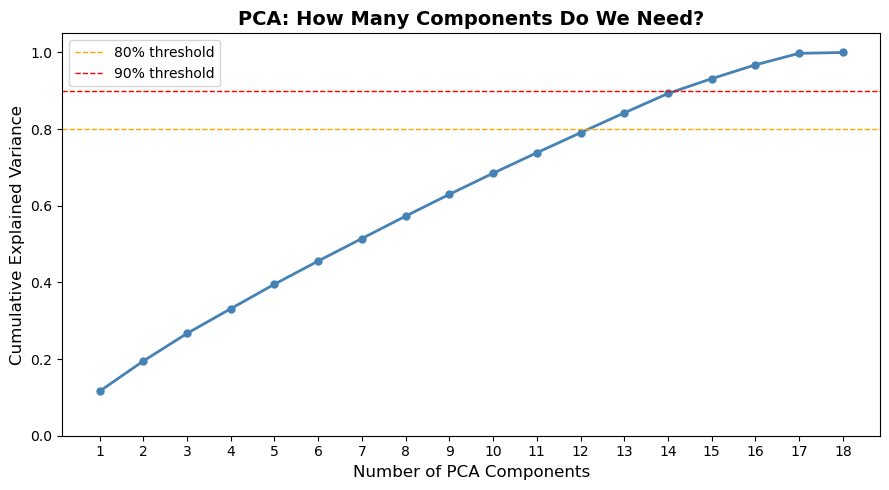

  1 components → 11.6% variance explained
  2 components → 19.5% variance explained
  3 components → 26.7% variance explained
  4 components → 33.1% variance explained
  5 components → 39.5% variance explained
  6 components → 45.6% variance explained
  7 components → 51.5% variance explained
  8 components → 57.3% variance explained
  9 components → 63.0% variance explained
  10 components → 68.5% variance explained
  11 components → 73.8% variance explained
  12 components → 79.1% variance explained
  13 components → 84.2% variance explained
  14 components → 89.3% variance explained
  15 components → 93.2% variance explained
  16 components → 96.8% variance explained
  17 components → 99.8% variance explained
  18 components → 100.0% variance explained


In [90]:
# Run PCA with ALL components first, just to see how variance is distributed
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Cumulative explained variance
cumvar = pca_full.explained_variance_ratio_.cumsum()

# Plot
plt.figure(figsize=(9, 5))

plt.plot(range(1, len(cumvar)+1), cumvar,
         marker='o', color='steelblue', linewidth=2, markersize=5)

# Add threshold lines
plt.axhline(y=0.80, color='orange', linestyle='--', linewidth=1, label='80% threshold')
plt.axhline(y=0.90, color='red',    linestyle='--', linewidth=1, label='90% threshold')

plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA: How Many Components Do We Need?', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(range(1, len(cumvar)+1))
plt.ylim(0, 1.05)
plt.tight_layout()

plt.show()

# Print the numbers
for i, cv in enumerate(cumvar):
    print(f"  {i+1} components → {cv*100:.1f}% variance explained")

In [91]:
# Find the minimum number of components to explain 85% of variance
n_components_85 = np.argmax(cumvar >= 0.85) + 1
print(f"\nComponents needed for 85% explained variance: {n_components_85}")


Components needed for 85% explained variance: 14


Component 1 explains: 11.6% of variance
Component 2 explains: 7.9% of variance
Together: 19.5% of variance


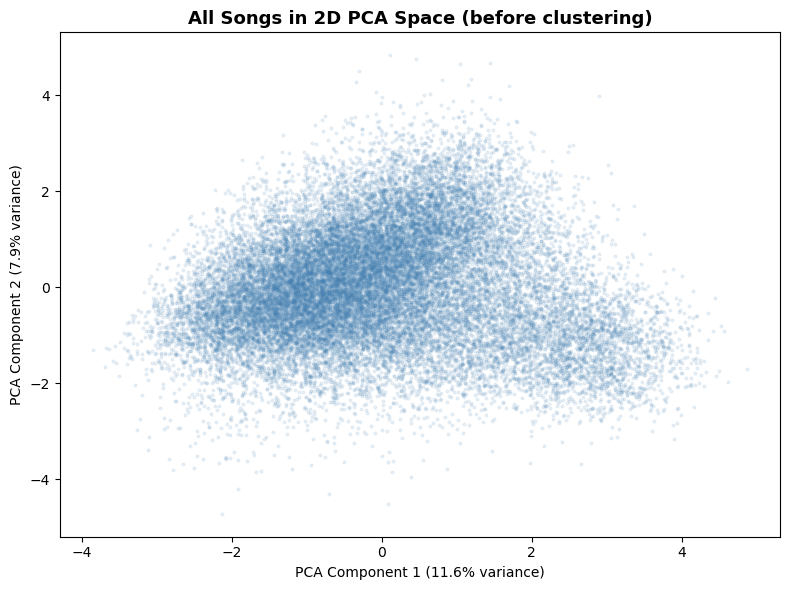

In [92]:
# Lets create a 2D PCA version for visualization

# 2D PCA — for scatter plot visualization only
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

# See how much variance these 2 components explain
print(f"Component 1 explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"Component 2 explains: {pca_2d.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Together: {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance")

# Quick scatter plot to see the overall shape of the data
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.1, s=4, color='steelblue')
plt.xlabel(f'PCA Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('All Songs in 2D PCA Space (before clustering)', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

In [93]:
# Save the Cleaned Data

df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   len                       28362 non-null  int64  
 2   dating                    28362 non-null  float64
 3   violence                  28362 non-null  float64
 4   world/life                28362 non-null  float64
 5   night/time                28362 non-null  float64
 6   shake the audience        28362 non-null  float64
 7   family/gospel             28362 non-null  float64
 8   romantic                  28362 non-null  float64
 9   communication             28362 non-null  float64
 10  obscene                   28362 non-null  float64
 11  music                     28362 non-null  float64
 12  movement/places           28362 non-null  float64
 13  light/visual perceptions  28362 non-null  float64
 14  family

In [ ]:
# Lets save everything we have done in this notebook






In [97]:
# Save all preprocessing outputs

base_path = '/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec'

# 1. Save scaled features
df_scaled.to_csv(f'{base_path}/train_cleaned_scaled.csv', index=False)
print("✓ Saved: train_cleaned_scaled.csv")

# 2. Save the unscaled (but cleaned) version
df_features.to_csv(f'{base_path}/train_cleaned_unscaled.csv', index=False)
print("✓ Saved: train_cleaned_unscaled.csv")

# 3. Save the 2D PCA coordinates
df_pca_2d = pd.DataFrame(
    X_2d,
    columns=['pca_1', 'pca_2']
)
df_pca_2d.to_csv(f'{base_path}/pca_2d_coords.csv', index=False)
print("✓ Saved: pca_2d_coords.csv")

# 4. Save the scaler so we can reuse it on test data
joblib.dump(scaler, f'{base_path}/scaler.pkl')
print("✓ Saved: scaler.pkl")

print("\n✓ All preprocessing outputs saved successfully!")


✓ Saved: train_cleaned_scaled.csv
✓ Saved: train_cleaned_unscaled.csv
✓ Saved: pca_2d_coords.csv
✓ Saved: scaler.pkl

✓ All preprocessing outputs saved successfully!
